In [ ]:
#!pip install xgboost

In [ ]:
#!pip install lightgbm

In [1]:
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report, mean_squared_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
import xgboost as xgb

## Classification

In [3]:
data = pd.read_csv('../../datasets/pima_indians_diabetes.csv')
data.head()

,preg,plas,pres,skin,test,mass,pedi,age,class
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
X = data.drop('class', axis=1)
y = data['class']

In [5]:
X.head()

,preg,plas,pres,skin,test,mass,pedi,age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [6]:
y.head()

0    1
1    0
2    1
3    0
4    1
Name: class, dtype: int64

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((614, 8), (154, 8), (614,), (154,))

In [16]:
xgb_clf = xgb.XGBClassifier(max_depth=6, reg_lambda=0.5, reg_alpha=1.0)
xgb_clf.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [17]:
yhat_train = xgb_clf.predict(X_train)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       401
           1       1.00      1.00      1.00       213

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614



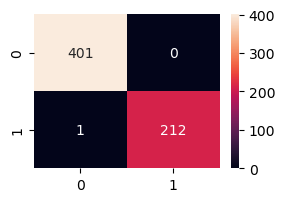

In [18]:
plt.figure(figsize=(3,2))
cm = confusion_matrix(y_train, yhat_train)
print(classification_report(y_train, yhat_train))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [19]:
yhat_test = xgb_clf.predict(X_test)

              precision    recall  f1-score   support

           0       0.82      0.74      0.78        99
           1       0.60      0.71      0.65        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154



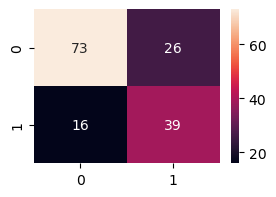

In [20]:
plt.figure(figsize=(3,2))
cm = confusion_matrix(y_test, yhat_test)
print(classification_report(y_test, yhat_test))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

### Lightgbm

In [21]:
import lightgbm as lgb

/opt/anaconda3/envs/mlp/lib/python3.12/site-packages/dask/dataframe/__init__.py:49: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [22]:
lgb_clf = lgb.LGBMClassifier(verbose=0)
lgb_clf.fit(X_train,y_train)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

LGBMClassifier(verbose=0)

In [23]:
yhat_train = lgb_clf.predict(X_train)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       401
           1       1.00      1.00      1.00       213

    accuracy                           1.00       614
   macro avg       1.00      1.00      1.00       614
weighted avg       1.00      1.00      1.00       614



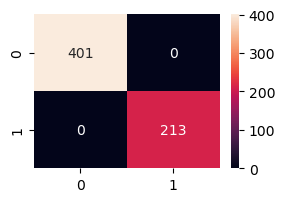

In [24]:
plt.figure(figsize=(3,2))
cm = confusion_matrix(y_train, yhat_train)
print(classification_report(y_train, yhat_train))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [25]:
yhat_test = lgb_clf.predict(X_test)

              precision    recall  f1-score   support

           0       0.81      0.74      0.77        99
           1       0.59      0.69      0.64        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.71       154
weighted avg       0.73      0.72      0.72       154



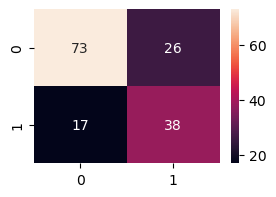

In [26]:
plt.figure(figsize=(3,2))
cm = confusion_matrix(y_test, yhat_test)
print(classification_report(y_test, yhat_test))
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

## Regression

In [27]:
price = pd.read_csv('../../datasets/boston.csv')
price.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,House Price
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [28]:
X = price.drop('House Price', axis =1)
y = price['House Price']

In [29]:
X.head(3)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03


In [30]:
y.head(3)

0    24.0
1    21.6
2    34.7
Name: House Price, dtype: float64

In [31]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2, random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((404, 13), (102, 13), (404,), (102,))

#### Xgboost

In [32]:
xgb_reg = xgb.XGBRegressor()
xgb_reg.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=None, ...)

In [33]:
yhat_train = xgb_reg.predict(X_train)

In [34]:
train_mse = mean_squared_error(y_train,yhat_train)
train_mse

0.0002620971899759447

In [35]:
train_rmse = np.sqrt(train_mse)
train_rmse

0.016189415986253015

In [36]:
yhat_test = xgb_reg.predict(X_test)

In [37]:
test_mse = mean_squared_error(y_test,yhat_test)
test_rmse = np.sqrt(test_mse)

In [38]:
test_mse,test_rmse

(6.909231565384943, 2.62854171840299)

### Lightgbm

In [39]:
lgb_reg = lgb.LGBMRegressor()
lgb_reg.fit(X_train,y_train)

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

LGBMRegressor()

In [40]:
yhat_train = lgb_reg.predict(X_train)

In [41]:
train_mse = mean_squared_error(y_train,yhat_train)
train_rmse = np.sqrt(train_mse)

In [42]:
train_mse,train_rmse

(2.283274828551085, 1.5110509020384075)

In [43]:
yhat_test = lgb_reg.predict(X_test)

In [44]:
test_mse = mean_squared_error(y_test,yhat_test)
test_rmse = np.sqrt(test_mse)

In [45]:
test_mse,test_rmse

(8.338757275893952, 2.887690647540687)

<font color='red'>__ToDo__ : Do hyperparam tuning using Gridsearch </font>